In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('../data/processed/flats_clean.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.shape

(545, 13)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [5]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


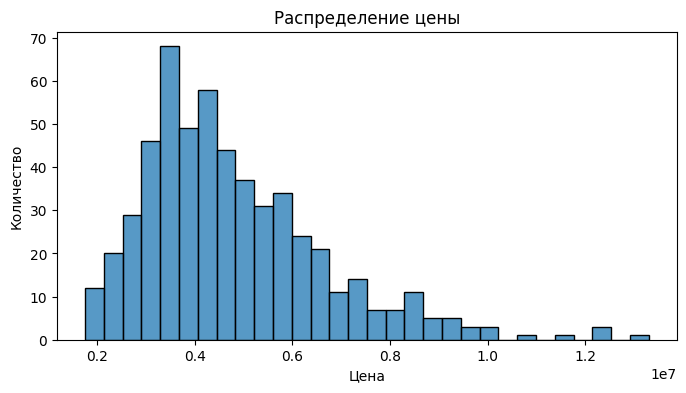

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(df['price'], bins=30)
plt.title('Распределение цены')
plt.xlabel('Цена')
plt.ylabel('Количество')
plt.show()

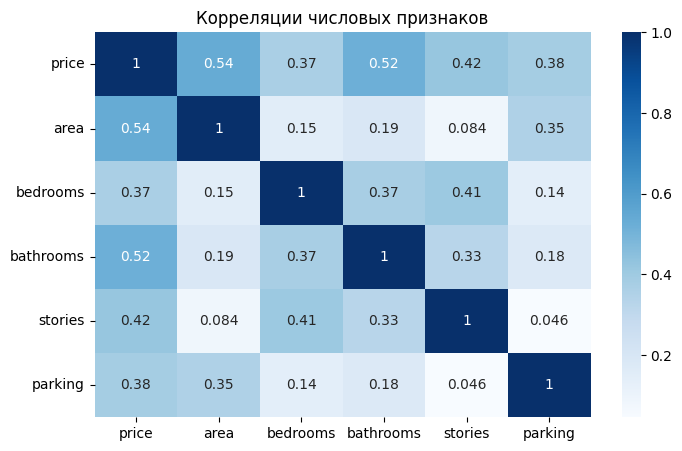

In [7]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='Blues')
plt.title('Корреляции числовых признаков')
plt.show()

In [8]:
target = 'price'

features = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'parking',
    'prefarea',
    'furnishingstatus'
]

cat_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea',
    'furnishingstatus'
]

cat_features = [features.index(col) for col in cat_columns]

X = df[features]
y = df[target]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
params = {
    'iterations': 500,
    'learning_rate': 0.05,
    'depth': 6,
    'random_seed': 42,
    'train_dir': '../src/catboost_info',
    'verbose': 100
}

model = CatBoostRegressor(**params, loss_function='RMSE')
low_model = CatBoostRegressor(**params, loss_function='Quantile:alpha=0.1')
high_model = CatBoostRegressor(**params, loss_function='Quantile:alpha=0.9')

In [11]:
model.fit(X_train, y_train, cat_features=cat_features)
low_model.fit(X_train, y_train, cat_features=cat_features)
high_model.fit(X_train, y_train, cat_features=cat_features)

0:	learn: 1718193.9722222	total: 56.7ms	remaining: 28.3s
100:	learn: 803951.5372003	total: 90.6ms	remaining: 358ms
200:	learn: 637038.7001003	total: 120ms	remaining: 178ms
300:	learn: 560399.4277371	total: 151ms	remaining: 99.6ms
400:	learn: 506792.6163884	total: 180ms	remaining: 44.4ms
499:	learn: 466031.1028434	total: 210ms	remaining: 0us
0:	learn: 220224.4471822	total: 322us	remaining: 161ms
100:	learn: 102349.3367541	total: 33.1ms	remaining: 131ms
200:	learn: 82379.3738442	total: 65.8ms	remaining: 97.8ms
300:	learn: 75541.6296726	total: 95.8ms	remaining: 63.3ms
400:	learn: 71354.2176442	total: 126ms	remaining: 31.1ms
499:	learn: 67639.6506912	total: 156ms	remaining: 0us
0:	learn: 373268.3626870	total: 372us	remaining: 186ms
100:	learn: 122642.0713124	total: 29.8ms	remaining: 118ms
200:	learn: 97921.7877090	total: 60.4ms	remaining: 89.8ms
300:	learn: 90179.0241482	total: 94.1ms	remaining: 62.2ms
400:	learn: 84992.5206582	total: 125ms	remaining: 30.9ms
499:	learn: 80210.4316810	total

CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='Quantile:alpha=0.9', random_seed=42, train_dir='../src/catboost_info', verbose=100)

In [12]:
pred = model.predict(X_test)
low_pred = low_model.predict(X_test)
high_pred = high_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)
mape = np.mean(np.abs((y_test - pred) / y_test)) * 100
median_error = np.median(np.abs(y_test - pred))

in_interval = ((y_test >= low_pred) & (y_test <= high_pred)).mean() * 100
average_width = np.mean(high_pred - low_pred)

print('MAE:', round(mae, 2))
print('RMSE:', round(rmse, 2))
print('R2:', round(r2, 3))
print('MAPE:', round(mape, 2), '%')
print('Median AE:', round(median_error, 2))
print('Попадание в интервал:', round(in_interval, 2), '%')
print('Средняя ширина интервала:', round(average_width, 2))

MAE: 977927.67
RMSE: 1327276.86
R2: 0.651
MAPE: 21.11 %
Median AE: 761993.54
Попадание в интервал: 44.95 %
Средняя ширина интервала: 1441586.81


In [13]:
results = pd.DataFrame({
    'real_price': y_test.values,
    'prediction': pred,
    'low': low_pred,
    'high': high_pred
})

results.head(10)

,real_price,prediction,low,high
0,4060000,5.663800e+06,4.460895e+06,6.675425e+06
1,6650000,7.851584e+06,6.545742e+06,8.134499e+06
2,3710000,3.507804e+06,2.950703e+06,3.970230e+06
3,6440000,4.453917e+06,3.964651e+06,5.290666e+06
4,2800000,3.830190e+06,3.239001e+06,4.263818e+06
5,4900000,3.653563e+06,2.931935e+06,4.140603e+06
6,5250000,5.746378e+06,4.522156e+06,6.687351e+06
7,4543000,5.597788e+06,5.134045e+06,6.494955e+06
8,2450000,2.893933e+06,2.268385e+06,3.239127e+06
9,3353000,2.979264e+06,2.790166e+06,3.530243e+06


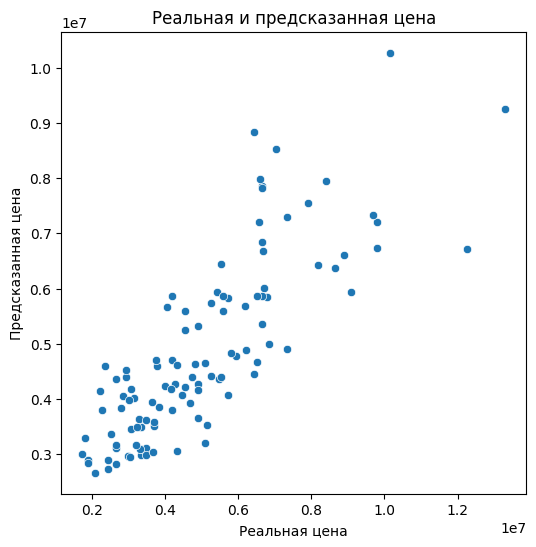

In [14]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=results['real_price'], y=results['prediction'])
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title('Реальная и предсказанная цена')
plt.show()

In [15]:
model.save_model('../models/catboost_model.cbm')
low_model.save_model('../models/catboost_low.cbm')
high_model.save_model('../models/catboost_high.cbm')